In [2]:
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, BisectingKMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import scipy
from kneed import KneeLocator
from typing import Tuple, Literal, Any, Optional
import scipy.stats as stats
from gensim.models import KeyedVectors
import re
from mpl_toolkits.mplot3d import Axes3D 
import matplotlib as mpl
from cycler import cycler
from utils import *
from utils import find_elbow, _remap


In [3]:
print(sanity_check())

Version 3


In [4]:
mpl.rcParams['axes.prop_cycle'] = cycler(color=['teal', 'maroon', 'steelblue', '#3EB489', '#6B8E23'])

In [5]:
df = pd.read_csv('data/DSU-Dataset.csv', parse_dates=['Date'], dtype={'Hour':'int32'})
display(df)

,Site,Date,Hour,REASON_VISIT_NAME,ED Enc,ED Enc Admitted
0,A,2018-01-01,0,BREATHING PROBLEM,1,1
1,A,2018-01-01,0,BURN,1,0
2,A,2018-01-01,0,SHAKING,1,1
3,A,2018-01-01,0,VOMITING,1,0
4,A,2018-01-01,1,FROSTBITE,1,0
...,...,...,...,...,...,...
1174305,D,2025-08-31,22,KNEE INJURY,1,0
1174306,D,2025-08-31,23,CHEST PAIN,1,0
1174307,D,2025-08-31,23,DIZZINESS,1,0
1174308,D,2025-08-31,23,FINGER PAIN,1,0


In [6]:
display(df.isna().sum())

Site                    0
Date                    0
Hour                    0
REASON_VISIT_NAME    6205
ED Enc                  0
ED Enc Admitted         0
dtype: int64

In [7]:
df.describe()

,Date,Hour,ED Enc,ED Enc Admitted
count,1174310,1.174310e+06,1.174310e+06,1.174310e+06
mean,2021-12-05 23:13:59.314321664,1.354932e+01,1.084646e+00,2.915218e-01
min,2018-01-01 00:00:00,0.000000e+00,1.000000e+00,0.000000e+00
25%,2019-12-23 00:00:00,1.000000e+01,1.000000e+00,0.000000e+00
50%,2021-12-30 00:00:00,1.400000e+01,1.000000e+00,0.000000e+00
75%,2023-11-11 00:00:00,1.900000e+01,1.000000e+00,1.000000e+00
max,2025-08-31 00:00:00,2.300000e+01,8.000000e+00,5.000000e+00
std,NaN,6.142173e+00,3.228135e-01,4.772703e-01


In [8]:
df['ED Enc Admitted'].sum() / df['ED Enc'].sum() # overall admission rate

np.float64(0.26877133038813356)

In [9]:
df.REASON_VISIT_NAME.fillna('NaN', inplace=True)

/tmp/ipykernel_283376/2663292634.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.REASON_VISIT_NAME.fillna('NaN', inplace=True)


## Reason of encounter analysis

In [10]:
unique_reasons = df['REASON_VISIT_NAME'].unique()
unique_reasons.sort()

In [11]:
reason_count = (
    df.groupby('REASON_VISIT_NAME')
      .agg(
          total_occurences_of_reason=('REASON_VISIT_NAME', 'size'),
          total_visits=('ED Enc', 'sum'),
          total_admitted=('ED Enc Admitted', 'sum')
      )
      .sort_values(by='total_visits', ascending=False)
)
reason_count['percentage_of_admission'] = (reason_count['total_admitted'] / reason_count['total_visits'])*100
display(reason_count)
reason_count.describe()

,total_occurences_of_reason,total_visits,total_admitted,percentage_of_admission
REASON_VISIT_NAME,,,,
ABDOMINAL PAIN,94739,123575,36534,29.564232
CHEST PAIN,68213,82502,31341,37.988170
FALL,46042,52970,19569,36.943553
SHORTNESS OF BREATH,42243,48018,27345,56.947395
BACK PAIN,32299,35338,5849,16.551588
...,...,...,...,...
ADENOPATHY,1,1,1,100.000000
UPPER GI PROCEDURE,1,1,1,100.000000
ACCESSORY NIPPLE,1,1,0,0.000000


,total_occurences_of_reason,total_visits,total_admitted,percentage_of_admission
count,868.000000,868.000000,868.000000,868.000000
mean,1352.891705,1467.408986,394.397465,26.166079
std,5481.191807,6532.125310,2215.047504,28.091508
min,1.000000,1.000000,0.000000,0.000000
25%,5.000000,5.000000,1.000000,2.976139
50%,38.500000,39.000000,7.000000,16.609127
75%,503.000000,504.500000,91.000000,42.145464
max,94739.000000,123575.000000,36534.000000,100.000000


<Axes: xlabel='REASON_VISIT_NAME'>

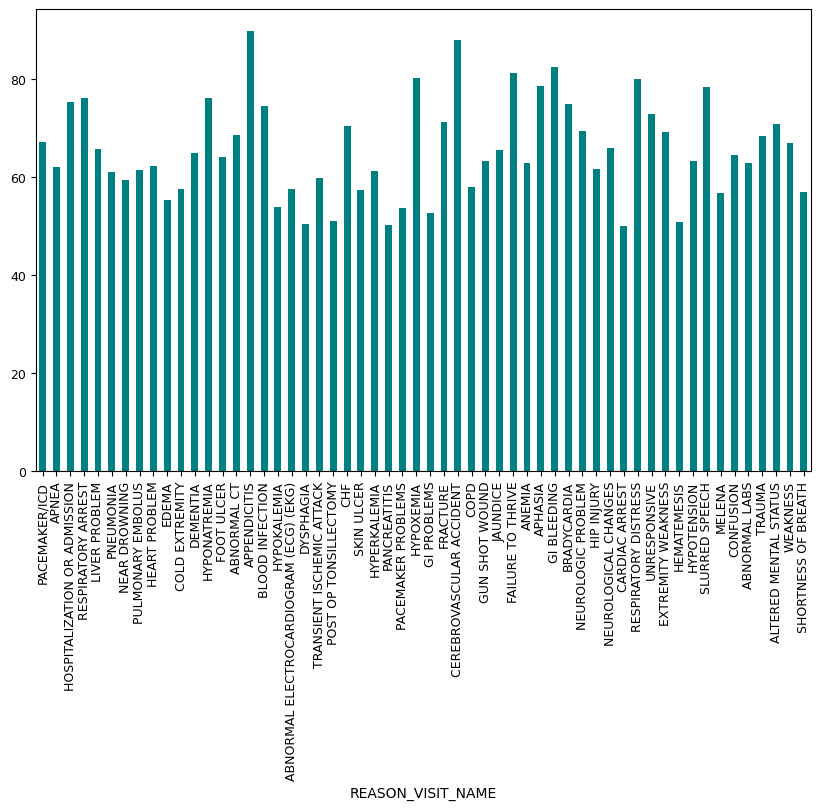

In [12]:
importance_df = reason_count[(reason_count['percentage_of_admission']>50) & (reason_count['total_visits']>50)].sort_values(by='total_occurences_of_reason', ascending=True)
importance_df['percentage_of_admission'].plot(kind='bar', figsize=(10,6), fontsize=9)

## Date/Time analysis

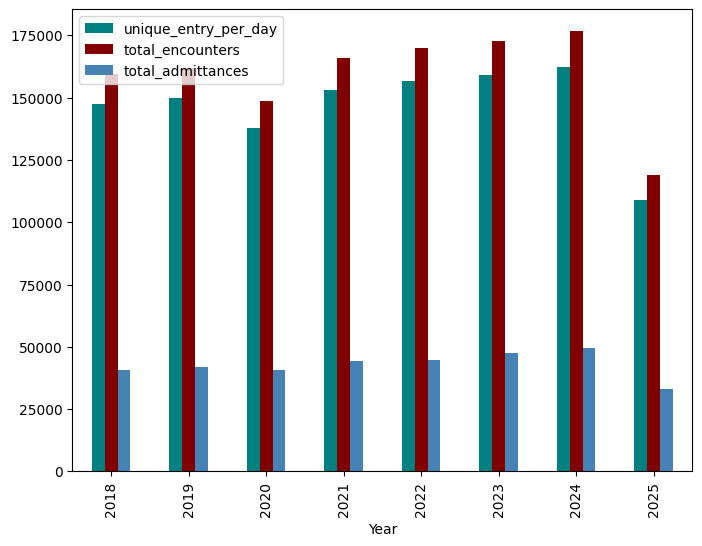

In [13]:
# year
grouped_by_year = df.groupby(by = df['Date'].dt.year).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_year.plot(kind='bar', figsize=(8,6), xlabel='Year')
plt.show()

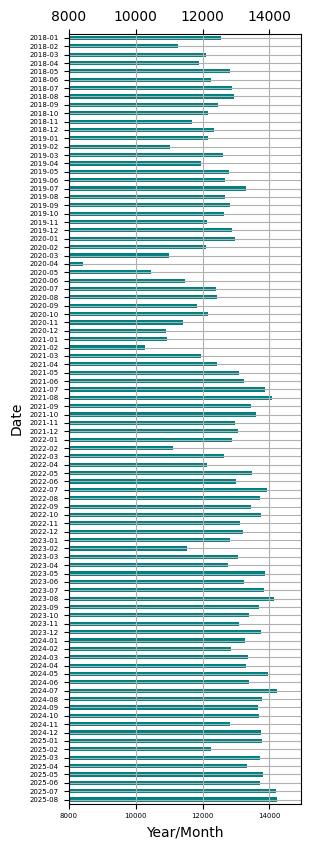

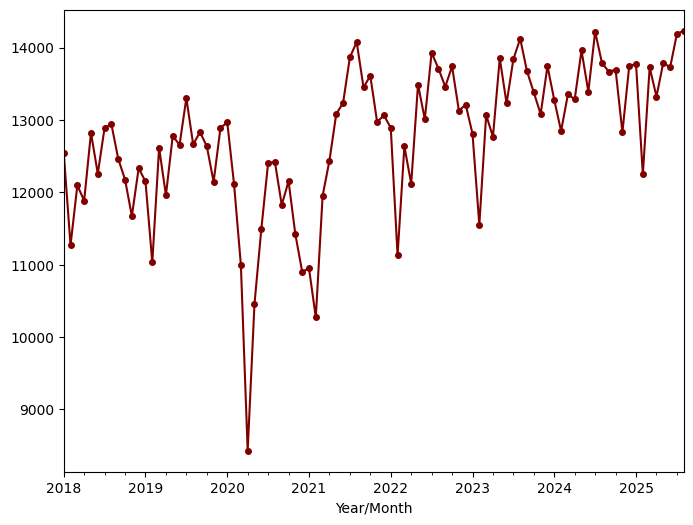

In [14]:
# year/month
grouped_by_year_month = df.groupby(by = df['Date'].dt.to_period('M')).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
# for i in range(2018,2026):
#     grouped_by_year.loc[i].plot.bar()

ax1 = grouped_by_year_month['unique_entry_per_day'].plot(kind='barh', figsize = (3,10), xlabel='Year/Month', xlim=8000, grid=True, fontsize=5)
ax1.invert_yaxis()
ax1.tick_params(top=True, labeltop=True)
plt.show()
ax2 = grouped_by_year_month['unique_entry_per_day'].plot(kind='line', figsize = (8,6), xlabel='Year/Month', color='maroon', marker='o', markersize=4)
plt.show()


In [15]:
grouped_by_year_month.to_csv('data/grouped_by_year_month.csv')

,unique_entry_per_day,total_encounters,total_admissions,admission_ratio
Date,,,,
1,87596,95389,25518,0.267515
2,80217,87108,23276,0.267209
3,86727,94102,25320,0.269070
4,82892,89607,24630,0.274867
5,90455,97616,26399,0.270437
6,89273,96345,26025,0.270123
7,94468,101979,26880,0.263584
8,93729,101648,26929,0.264924
9,91378,98973,26058,0.263284


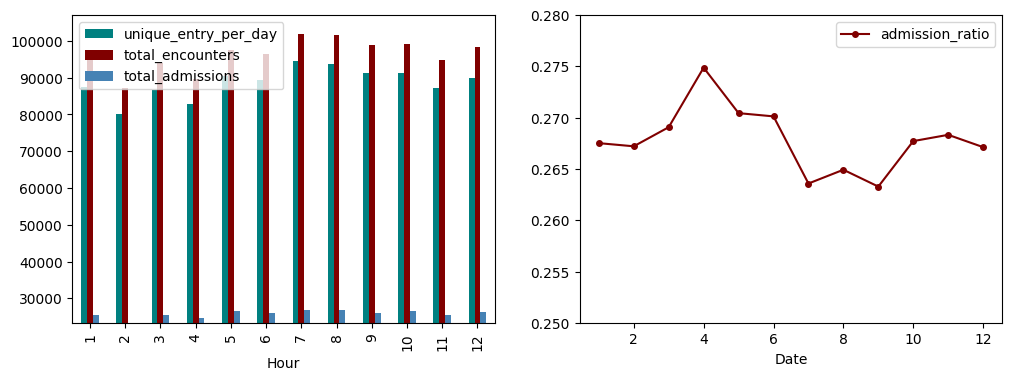

In [16]:
# month
grouped_by_month = df[df['Date'].dt.year < 2025].groupby(by = df['Date'].dt.month).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admissions = ('ED Enc Admitted', 'sum')
    )
grouped_by_month['admission_ratio'] = (grouped_by_month['total_admissions'] / grouped_by_month['total_encounters'])
display(grouped_by_month)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))  
grouped_by_month.iloc[:,:-1].plot(kind='bar', xlabel='Hour', ylim=grouped_by_month.iloc[:,:-1].min()['total_admissions'], ax=axes[0])
grouped_by_month['admission_ratio'].plot(kind='line', ylim=(0.25, 0.28), ax=axes[1], color='maroon', legend=True, marker='o', markersize=4)
plt.show()

,unique_entry_per_day,total_encounters,total_admissions,admission_ratio
Date,,,,
1,38527,41836,11127,0.265967
2,38640,42038,11151,0.265260
3,39098,42388,11273,0.265948
4,38574,41786,11116,0.266022
5,38910,42244,11342,0.268488


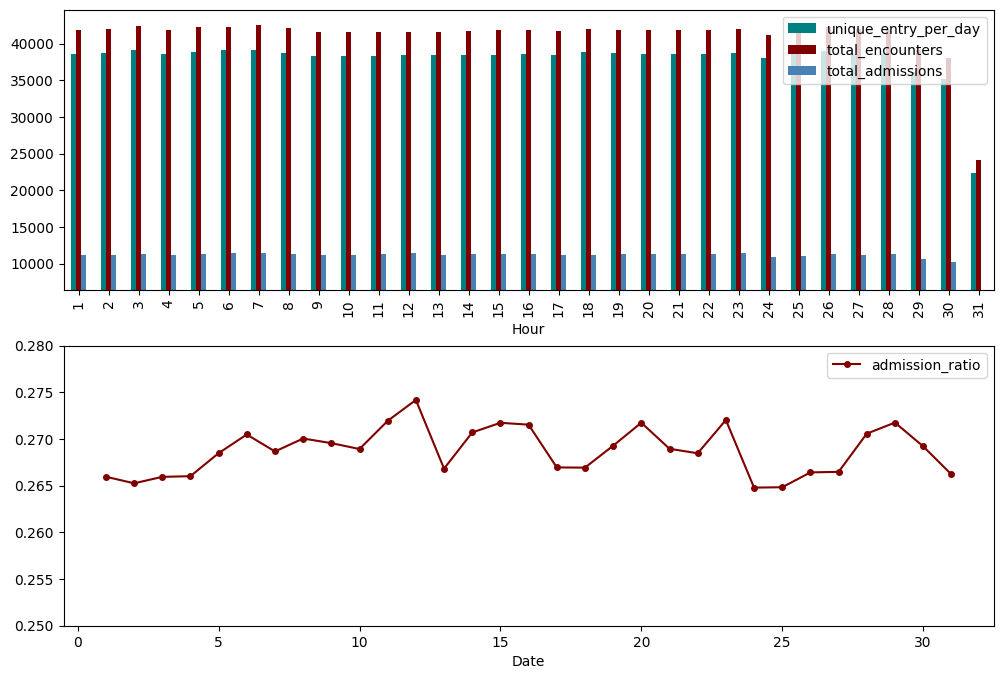

In [17]:
# day of the month
grouped_by_day = df.groupby(by = df['Date'].dt.day).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admissions = ('ED Enc Admitted', 'sum')
    )
grouped_by_day['admission_ratio'] = (grouped_by_day['total_admissions'] / grouped_by_day['total_encounters'])
display(grouped_by_day.head(5))

fig, axes = plt.subplots(2, 1, figsize=(12, 8))  
grouped_by_day.iloc[:,:-1].plot(kind='bar', xlabel='Hour', ylim=grouped_by_day.iloc[:,:-1].min()['total_admissions'], ax=axes[0])
grouped_by_day['admission_ratio'].plot(kind='line', ylim=(0.25, 0.28), ax=axes[1], color='maroon', legend=True, marker='o', markersize=4)
plt.show()

# grouped_by_day.plot(kind='bar', figsize = (15,6), xlabel='Day of the month')

,unique_entry_per_day,total_encounters,total_admissions,admission_ratio
Date,,,,
0,176124,192519,52940,0.274986
1,166491,181060,49882,0.275500
2,165012,179035,49507,0.276521
3,162961,176553,49012,0.277605
4,165587,179223,49973,0.278831
5,167234,180421,44874,0.248718
6,170901,184900,46149,0.249589


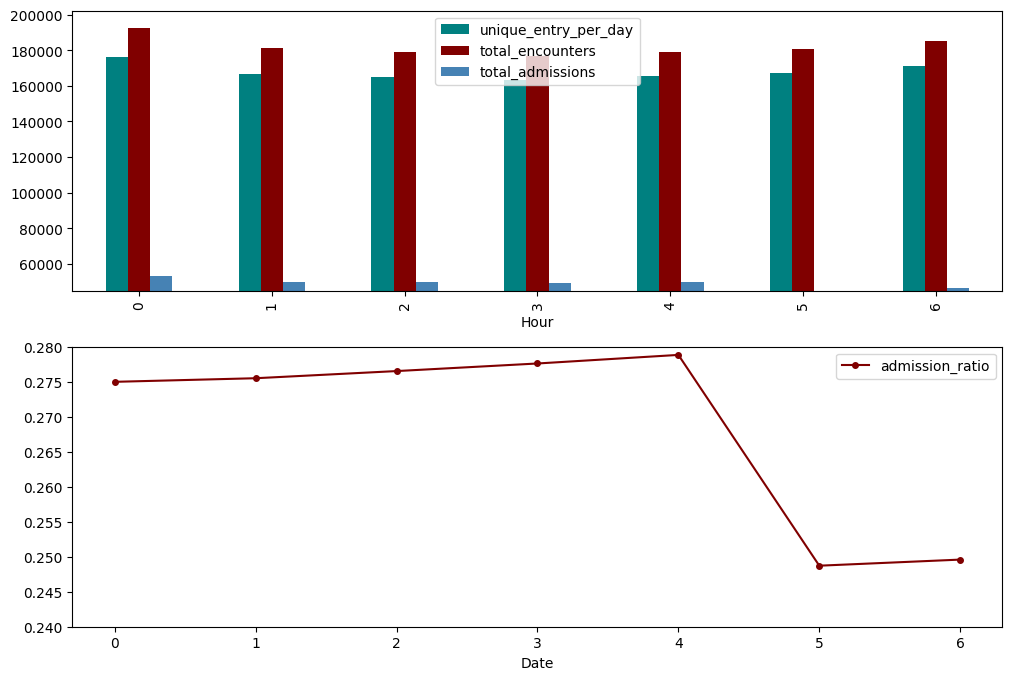

In [18]:
# day of the week
grouped_by_day_of_week = df.groupby(by = df['Date'].dt.day_of_week).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admissions = ('ED Enc Admitted', 'sum')
    )

grouped_by_day_of_week['admission_ratio'] = (grouped_by_day_of_week['total_admissions'] / grouped_by_day_of_week['total_encounters'])
display(grouped_by_day_of_week)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))  
grouped_by_day_of_week.iloc[:,:-1].plot(kind='bar', xlabel='Hour', ylim=grouped_by_day_of_week.iloc[:,:-1].min()['total_admissions'], ax=axes[0])
grouped_by_day_of_week['admission_ratio'].plot(kind='line', ylim=(0.24, 0.28), ax=axes[1], color='maroon', legend=True, marker='o', markersize=4)
plt.show()

In [28]:
grouped_by_year_month_week = df.groupby(by = df['Date'].dt.to_period('W')).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
# for i in range(2018,2026):
#     grouped_by_year.loc[i].plot.bar()

display(grouped_by_year_month_week.index)
# grouped_by_year_month_week.to_csv('/home/uplong/Documents/DSU-analytics-comp-2026/data/grouped_by_year_month_week.csv')

# ax2 = grouped_by_year_month_week['unique_entry_per_day'].plot(kind='line', figsize = (14,8), xlabel='Year/Month', color='maroon', marker='o', markersize=4)
# plt.show()

PeriodIndex(['2018-01-01/2018-01-07', '2018-01-08/2018-01-14',
             '2018-01-15/2018-01-21', '2018-01-22/2018-01-28',
             '2018-01-29/2018-02-04', '2018-02-05/2018-02-11',
             '2018-02-12/2018-02-18', '2018-02-19/2018-02-25',
             '2018-02-26/2018-03-04', '2018-03-05/2018-03-11',
             ...
             '2025-06-23/2025-06-29', '2025-06-30/2025-07-06',
             '2025-07-07/2025-07-13', '2025-07-14/2025-07-20',
             '2025-07-21/2025-07-27', '2025-07-28/2025-08-03',
             '2025-08-04/2025-08-10', '2025-08-11/2025-08-17',
             '2025-08-18/2025-08-24', '2025-08-25/2025-08-31'],
            dtype='period[W-SUN]', name='Date', length=400)

In [ ]:
# grouped_by_year_reasons = df.groupby(by = [df['Date'].dt.year, df['REASON_VISIT_NAME']]).agg('size')
# grouped_by_year_reasons = grouped_by_year_reasons.reset_index()
# display(grouped_by_year_reasons[(grouped_by_year_reasons[0] > 500)],
#         grouped_by_year_reasons[(grouped_by_year_reasons[0] > 500) & (grouped_by_year_reasons['REASON_VISIT_NAME']=='ALLERGIC REACTION')]
# )

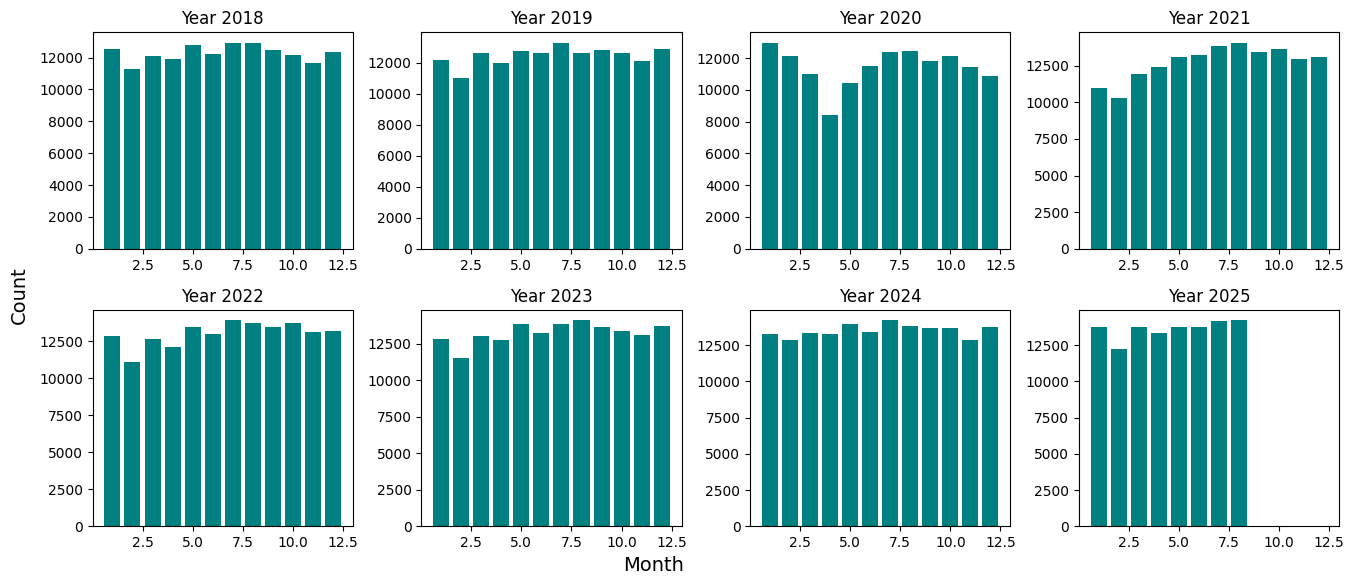

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14,6))  
axes = axes.flatten() 

years = range(2018, 2026) 

for idx, j in enumerate(years):
    df_year = df[df['Date'].dt.year == j]
    test = df_year.groupby([df_year['Date'].dt.month, df_year['REASON_VISIT_NAME']]).size()

    count_of_reasons_per_month = [test.loc[i].sum() if i in test.index.levels[0] else 0 for i in range(1, 13)]

    axes[idx].bar(range(1, 13), count_of_reasons_per_month)
    axes[idx].set_title(f"Year {j}")
    # axes[idx].set_xlabel("Month")
    # axes[idx].set_ylabel("Count")

for ax in axes[len(years):]:
    fig.delaxes(ax)

fig.text(0.5, 0.04, 'Month', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Count', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()


,unique_entry_per_day,total_encounters,total_admittances,admitance_rate
Hour,,,,
0,33787,35636,8566,0.240375
1,27544,28936,7239,0.250173
2,23897,24997,6407,0.256311
3,20988,21860,5821,0.266285
4,19275,20052,5518,0.275185
5,19152,19918,5497,0.275982
6,22332,23300,6211,0.266567
7,28746,30209,7998,0.264756
8,40757,43750,11882,0.271589


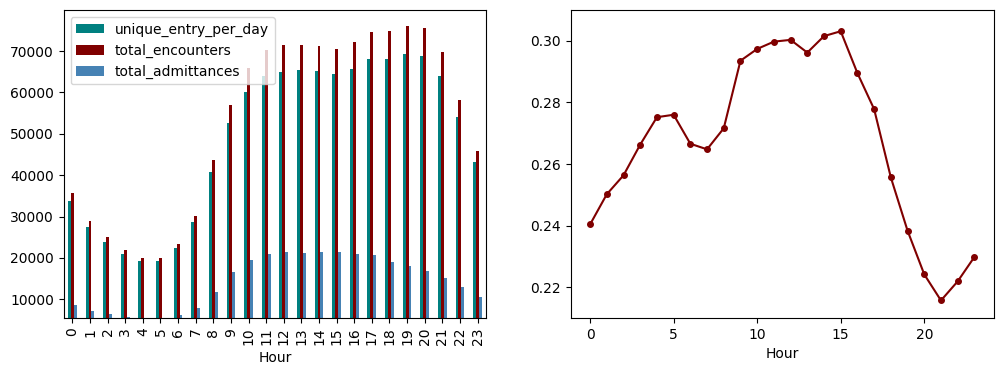

In [ ]:
grouped_by_time = df.groupby(by = df['Hour']).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
grouped_by_time['admitance_rate'] = grouped_by_time['total_admittances'] / grouped_by_time['total_encounters']
display(grouped_by_time)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  
grouped_by_time.iloc[:,:-1].plot(kind='bar', xlabel='Hour', ylim=grouped_by_time.iloc[:,:-1].min()['total_admittances'], ax=axes[0])
grouped_by_time['admitance_rate'].plot(kind='line', ylim=(0.21,0.31), ax=axes[1], color='maroon', marker='o', markersize=4)
plt.show()


## Analysis by site

,site,total_encounters,total_admittances,admittance_rate
Site,,,,
A,308478,339622,107210,0.315674
B,423139,463877,118092,0.254576
C,250370,267847,81899,0.305768
D,192323,202365,35136,0.173627


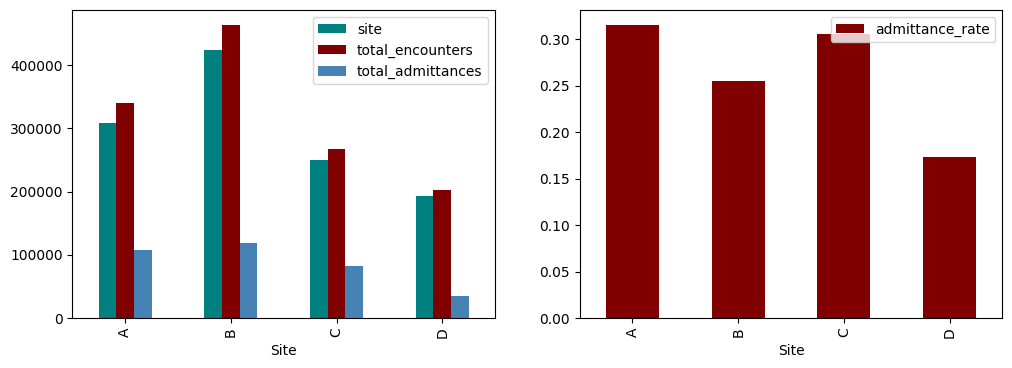

In [ ]:
grouped_by_site = df.groupby(by='Site').agg(
    site = ('Site', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
grouped_by_site['admittance_rate'] = grouped_by_site['total_admittances'] /grouped_by_site['total_encounters']
display(grouped_by_site)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
grouped_by_site.iloc[:,:-1].plot(kind='bar', ax=axes[0]) # finally some sort of imbalance
grouped_by_site['admittance_rate'].plot(kind='bar', ax=axes[1], legend=True, color='maroon')
plt.show()

# Ways to move forward ? 

* Important: Decide on a forecasting model and start building it. Ideas: RNNs, Transformers, XGBoost, CatBoost (Gradient Boosting)

* Create a baseline.

* Divide and Conquer ? or should we all tackle the same part of the problem ? Come back to that after a baseline is set.

* Try different embedding models (BERT???????)

* Should we trust the clusters and do analytics using them ?

* Include models that are weighted using the rate_of_admission [DONE]

* Make a joint weight, out of the count of each REASON and the rate_of_admission [DONE]

In [ ]:
df = pd.read_csv('insterted_clusters.csv', parse_dates=['Date'])
df

,Unnamed: 0,Site,Date,Hour,REASON_VISIT_NAME,ED Enc,ED Enc Admitted,kmeans | tf-idf,kmeans | tf-idf | raw_count,kmeans | tf-idf | log_count,...,bkmeans | tf-idf,bkmeans | tf-idf | raw_count,bkmeans | tf-idf | log_count,bkmeans | tf-idf | admission_rate,bkmeans | tf-idf | joint,bkmeans | bwv,bkmeans | bwv | raw_count,bkmeans | bwv | log_count,bkmeans | bwv | admission_rate,bkmeans | bwv | joint
0,0,A,2018-01-01,0,BREATHING PROBLEM,1,1,2,2,3,...,2,2,1,2,17,9,5,5,11,4
1,1,A,2018-01-01,0,BURN,1,0,2,6,4,...,2,3,15,2,7,3,0,13,17,1
2,2,A,2018-01-01,0,SHAKING,1,1,2,6,4,...,2,3,10,2,7,13,8,4,4,9
3,3,A,2018-01-01,0,VOMITING,1,0,2,14,4,...,2,3,10,2,12,14,10,10,3,17
4,4,A,2018-01-01,1,FROSTBITE,1,0,2,6,4,...,2,3,10,2,7,3,0,13,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1174305,1174305,D,2025-08-31,22,KNEE INJURY,1,0,2,10,2,...,2,5,6,2,12,3,0,13,17,0
1174306,1174306,D,2025-08-31,23,CHEST PAIN,1,0,3,4,1,...,2,3,23,2,3,15,15,8,1,2
1174307,1174307,D,2025-08-31,23,DIZZINESS,1,0,2,1,4,...,2,3,10,2,7,14,14,9,3,17
1174308,1174308,D,2025-08-31,23,FINGER PAIN,1,0,3,6,1,...,2,3,23,2,3,15,13,8,1,2


In [ ]:
grouped_by_cluster_df = df.groupby(by='bkmeans | bwv | admission_rate').agg(
    total_enc=('ED Enc', 'sum'),
    total_adm=('ED Enc Admitted', 'sum')
)
grouped_by_cluster_df['admission_rate'] = grouped_by_cluster_df['total_adm'] / grouped_by_cluster_df['total_enc']

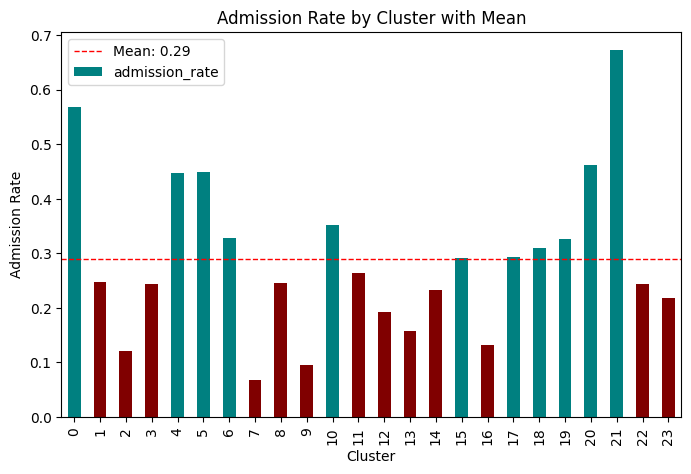

In [ ]:
mean_value = grouped_by_cluster_df['admission_rate'].mean()
colors = ['teal' if x >= mean_value else 'maroon' for x in grouped_by_cluster_df['admission_rate']]
ax = grouped_by_cluster_df['admission_rate'].plot(kind='bar', color=colors, figsize=(8,5))
plt.axhline(mean_value, color='red', linestyle='--', linewidth=1, label=f'Mean: {mean_value:.2f}')

plt.xlabel('Cluster')
plt.ylabel('Admission Rate')
plt.title('Admission Rate by Cluster with Mean')
plt.legend()

plt.show()

# Perhaps partition the clusters by importance given some threshold for each category.

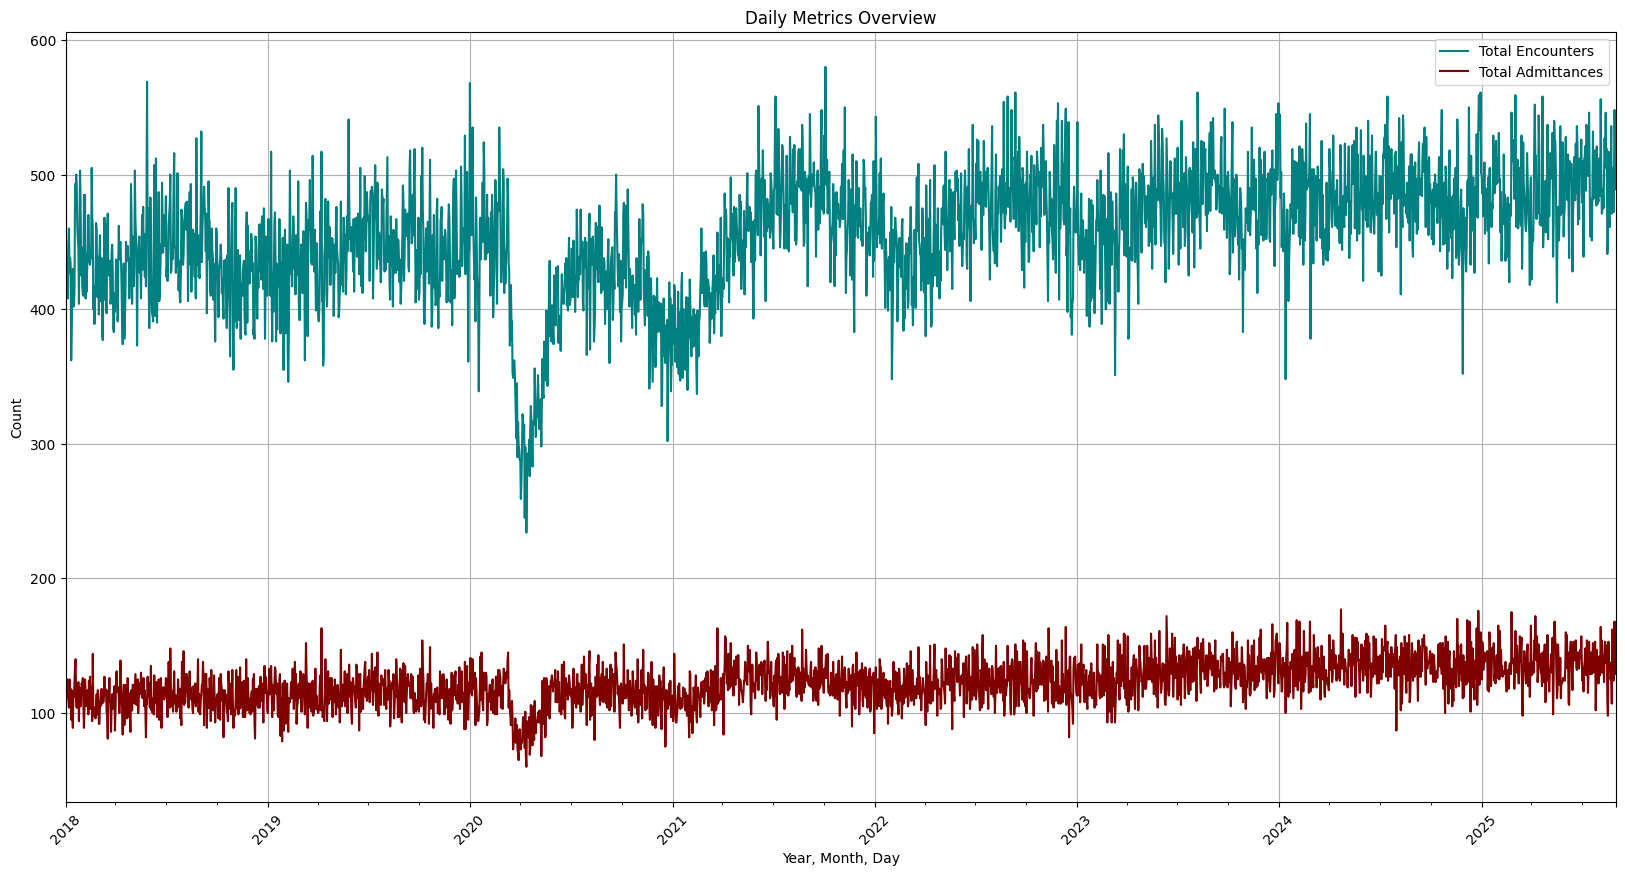

In [33]:
grouped_by_year_month_day = df.groupby(
    # [df['Date'].dt.year, df['Date'].dt.month, df['Date'].dt.day]
    df['Date'].dt.to_period('D')
).agg(
    unique_entry_per_day=('Date', 'size'),
    total_encounters=('ED Enc', 'sum'),
    total_admittances=('ED Enc Admitted', 'sum')
)

fig, ax = plt.subplots(figsize=(20,10))

grouped_by_year_month_day['total_encounters'].plot(
    kind='line', ax=ax, markersize=4, label='Total Encounters'
)
grouped_by_year_month_day['total_admittances'].plot(
    kind='line', ax=ax, markersize=4, label='Total Admittances'
)

ax.set_xlabel('Year, Month, Day')
ax.set_ylabel('Count')
ax.set_title('Daily Metrics Overview')
ax.legend()
ax.grid(True)

plt.xticks(rotation=45)

plt.show()


In [35]:
grouped_by_year_month_day.to_csv('/home/uplong/Documents/DSU-analytics-comp-2026/data/grouped_by_year_month_day.csv')